In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("crime_dataset_india.csv")

In [3]:
df.head()

,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


In [4]:
df.drop(columns=['Report Number','Time of Occurrence'],inplace =True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date Reported       40160 non-null  object
 1   Date of Occurrence  40160 non-null  object
 2   City                40160 non-null  object
 3   Crime Code          40160 non-null  int64 
 4   Crime Description   40160 non-null  object
 5   Victim Age          40160 non-null  int64 
 6   Victim Gender       40160 non-null  object
 7   Weapon Used         34370 non-null  object
 8   Crime Domain        40160 non-null  object
 9   Police Deployed     40160 non-null  int64 
 10  Case Closed         40160 non-null  object
 11  Date Case Closed    20062 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.7+ MB


In [6]:
df.isna().sum()

Date Reported             0
Date of Occurrence        0
City                      0
Crime Code                0
Crime Description         0
Victim Age                0
Victim Gender             0
Weapon Used            5790
Crime Domain              0
Police Deployed           0
Case Closed               0
Date Case Closed      20098
dtype: int64

In [7]:
df['Weapon Used'].unique()

array(['Blunt Object', 'Poison', 'Firearm', 'Other', 'Knife',
       'Explosives', nan], dtype=object)

In [8]:
df['Weapon Used'].value_counts()

Weapon Used
Knife           5835
Explosives      5751
Blunt Object    5737
Poison          5728
Other           5676
Firearm         5643
Name: count, dtype: int64

In [9]:
df['Weapon Used'].mode()[0]

'Knife'

In [10]:
df['Weapon Used'].fillna(df['Weapon Used'].mode()[0],inplace =True)

C:\Users\nalla\AppData\Local\Temp\ipykernel_10272\2174473696.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weapon Used'].fillna(df['Weapon Used'].mode()[0],inplace =True)


In [11]:
int(df['Weapon Used'].isna().sum())

0

In [12]:
df.isna().sum()

Date Reported             0
Date of Occurrence        0
City                      0
Crime Code                0
Crime Description         0
Victim Age                0
Victim Gender             0
Weapon Used               0
Crime Domain              0
Police Deployed           0
Case Closed               0
Date Case Closed      20098
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date Reported       40160 non-null  object
 1   Date of Occurrence  40160 non-null  object
 2   City                40160 non-null  object
 3   Crime Code          40160 non-null  int64 
 4   Crime Description   40160 non-null  object
 5   Victim Age          40160 non-null  int64 
 6   Victim Gender       40160 non-null  object
 7   Weapon Used         40160 non-null  object
 8   Crime Domain        40160 non-null  object
 9   Police Deployed     40160 non-null  int64 
 10  Case Closed         40160 non-null  object
 11  Date Case Closed    20062 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.7+ MB


In [14]:
df['Date Reported']=pd.to_datetime(df['Date Reported'],format="%d-%m-%Y %H:%M")

In [15]:
df['Date of Occurrence']=pd.to_datetime(df['Date of Occurrence'],format="%m-%d-%Y %H:%M" ,errors='coerce')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date Reported       40160 non-null  datetime64[ns]
 1   Date of Occurrence  40160 non-null  datetime64[ns]
 2   City                40160 non-null  object        
 3   Crime Code          40160 non-null  int64         
 4   Crime Description   40160 non-null  object        
 5   Victim Age          40160 non-null  int64         
 6   Victim Gender       40160 non-null  object        
 7   Weapon Used         40160 non-null  object        
 8   Crime Domain        40160 non-null  object        
 9   Police Deployed     40160 non-null  int64         
 10  Case Closed         40160 non-null  object        
 11  Date Case Closed    20062 non-null  object        
dtypes: datetime64[ns](2), int64(3), object(7)
memory usage: 3.7+ MB


In [17]:
df['Date Reported'].dt.minute.unique()

array([0], dtype=int32)

In [18]:
df['Date of Occurrence'].dt.minute.unique()

array([0], dtype=int32)

## PCA

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

# scaler=StandardScaler()
pca=PCA(n_components=1)

In [20]:
df['year_rep']=df['Date Reported'].dt.year
df['month_rep']=df['Date Reported'].dt.month
df['day_rep']=df['Date Reported'].dt.day
df['hr_rep']=df['Date Reported'].dt.hour

In [21]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed,year_rep,month_rep,day_rep,hr_rep
0,2020-01-02 00:00:00,2020-01-01 00:00:00,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN,2020,1,2,0
1,2020-01-01 19:00:00,2020-01-01 01:00:00,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN,2020,1,1,19


In [22]:
reported_fea=df[['year_rep','month_rep','day_rep','hr_rep']]

In [23]:
reported_fea.head()

,year_rep,month_rep,day_rep,hr_rep
0,2020,1,2,0
1,2020,1,1,19
2,2020,1,2,5
3,2020,1,1,5
4,2020,1,1,21


In [24]:
# scaled_reported=scaler.fit_transform(reported_fea)
scaled_reported=normalize(reported_fea)

In [25]:
scaled_reported

array([[9.99999387e-01, 4.95049202e-04, 9.90098403e-04, 0.00000000e+00],
       [9.99955522e-01, 4.95027486e-04, 4.95027486e-04, 9.40552224e-03],
       [9.99996324e-01, 4.95047685e-04, 9.90095370e-04, 2.47523843e-03],
       ...,
       [9.99990602e-01, 3.95253202e-03, 9.88133006e-04, 1.48219951e-03],
       [9.99948009e-01, 3.95236367e-03, 4.94045459e-04, 9.38686372e-03],
       [9.99841491e-01, 3.45794982e-03, 1.53137778e-02, 8.39787813e-03]])

In [26]:
df['PCA Date Reported']=pca.fit_transform(scaled_reported)

In [27]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed,year_rep,month_rep,day_rep,hr_rep,PCA Date Reported
0,2020-01-02 00:00:00,2020-01-01 00:00:00,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN,2020,1,2,0,-0.006878
1,2020-01-01 19:00:00,2020-01-01 01:00:00,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN,2020,1,1,19,-0.007269


In [28]:
df['year_occ']=df['Date of Occurrence'].dt.year
df['month_occ']=df['Date of Occurrence'].dt.month
df['day_occ']=df['Date of Occurrence'].dt.day
df['hr_occ']=df['Date of Occurrence'].dt.hour

In [29]:
occurence_fea=df[['year_occ','month_occ','day_occ','hr_occ']]

In [30]:
occurence_fea.head()

,year_occ,month_occ,day_occ,hr_occ
0,2020,1,1,0
1,2020,1,1,1
2,2020,1,1,2
3,2020,1,1,3
4,2020,1,1,4


In [31]:
# scaled_occurence=scaler.fit_transform(occurence_fea)
scaled_occurence=normalize(occurence_fea)

In [32]:
scaled_occurence

array([[9.99999755e-01, 4.95049384e-04, 4.95049384e-04, 0.00000000e+00],
       [9.99999632e-01, 4.95049323e-04, 4.95049323e-04, 4.95049323e-04],
       [9.99999265e-01, 4.95049141e-04, 4.95049141e-04, 9.90098282e-04],
       ...,
       [9.99873699e-01, 3.45806121e-03, 1.53142711e-02, 2.47004372e-03],
       [9.99872357e-01, 3.45805657e-03, 1.53142505e-02, 2.96404849e-03],
       [9.99870771e-01, 3.45805108e-03, 1.53142262e-02, 3.45805108e-03]])

In [33]:
df['PCA Occurance']=pca.fit_transform(scaled_occurence)

In [34]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,...,year_rep,month_rep,day_rep,hr_rep,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance
0,2020-01-02 00:00:00,2020-01-01 00:00:00,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,...,2020,1,2,0,-0.006878,2020,1,1,0,-0.007287
1,2020-01-01 19:00:00,2020-01-01 01:00:00,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,...,2020,1,1,19,-0.007269,2020,1,1,1,-0.007288


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date Reported       40160 non-null  datetime64[ns]
 1   Date of Occurrence  40160 non-null  datetime64[ns]
 2   City                40160 non-null  object        
 3   Crime Code          40160 non-null  int64         
 4   Crime Description   40160 non-null  object        
 5   Victim Age          40160 non-null  int64         
 6   Victim Gender       40160 non-null  object        
 7   Weapon Used         40160 non-null  object        
 8   Crime Domain        40160 non-null  object        
 9   Police Deployed     40160 non-null  int64         
 10  Case Closed         40160 non-null  object        
 11  Date Case Closed    20062 non-null  object        
 12  year_rep            40160 non-null  int32         
 13  month_rep           40160 non-null  int32     

In [36]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,...,year_rep,month_rep,day_rep,hr_rep,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance
0,2020-01-02 00:00:00,2020-01-01 00:00:00,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,...,2020,1,2,0,-0.006878,2020,1,1,0,-0.007287
1,2020-01-01 19:00:00,2020-01-01 01:00:00,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,...,2020,1,1,19,-0.007269,2020,1,1,1,-0.007288


In [37]:
df['Date Case Closed']

0                     NaN
1                     NaN
2                     NaN
3        29-04-2020 05:00
4        08-01-2020 21:00
               ...       
40155                 NaN
40156    29-09-2024 14:00
40157                 NaN
40158                 NaN
40159    28-09-2024 17:00
Name: Date Case Closed, Length: 40160, dtype: object

In [38]:
df['Date Case Closed']=df['Date Case Closed'].apply(lambda x: pd.NaT if pd.isna(x) else pd.to_datetime(x,format="%d-%m-%Y %H:%M"))

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date Reported       40160 non-null  datetime64[ns]
 1   Date of Occurrence  40160 non-null  datetime64[ns]
 2   City                40160 non-null  object        
 3   Crime Code          40160 non-null  int64         
 4   Crime Description   40160 non-null  object        
 5   Victim Age          40160 non-null  int64         
 6   Victim Gender       40160 non-null  object        
 7   Weapon Used         40160 non-null  object        
 8   Crime Domain        40160 non-null  object        
 9   Police Deployed     40160 non-null  int64         
 10  Case Closed         40160 non-null  object        
 11  Date Case Closed    20062 non-null  datetime64[ns]
 12  year_rep            40160 non-null  int32         
 13  month_rep           40160 non-null  int32     

In [40]:
df['Case Closed'].unique()

array(['No', 'Yes'], dtype=object)

In [41]:
df['Date Case Closed']=np.where(df['Case Closed']=='No',9999,
        (df['Date Case Closed']-df['Date Reported']).dt.days)

In [42]:
df.head()

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,...,year_rep,month_rep,day_rep,hr_rep,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance
0,2020-01-02 00:00:00,2020-01-01 00:00:00,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,...,2020,1,2,0,-0.006878,2020,1,1,0,-0.007287
1,2020-01-01 19:00:00,2020-01-01 01:00:00,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,...,2020,1,1,19,-0.007269,2020,1,1,1,-0.007288
2,2020-01-02 05:00:00,2020-01-01 02:00:00,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,...,2020,1,2,5,-0.006851,2020,1,1,2,-0.007288
3,2020-01-01 05:00:00,2020-01-01 03:00:00,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,...,2020,1,1,5,-0.007346,2020,1,1,3,-0.007289
4,2020-01-01 21:00:00,2020-01-01 04:00:00,Pune,421,VANDALISM,30,F,Other,Other Crime,18,...,2020,1,1,21,-0.007258,2020,1,1,4,-0.007289


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date Reported       40160 non-null  datetime64[ns]
 1   Date of Occurrence  40160 non-null  datetime64[ns]
 2   City                40160 non-null  object        
 3   Crime Code          40160 non-null  int64         
 4   Crime Description   40160 non-null  object        
 5   Victim Age          40160 non-null  int64         
 6   Victim Gender       40160 non-null  object        
 7   Weapon Used         40160 non-null  object        
 8   Crime Domain        40160 non-null  object        
 9   Police Deployed     40160 non-null  int64         
 10  Case Closed         40160 non-null  object        
 11  Date Case Closed    40160 non-null  float64       
 12  year_rep            40160 non-null  int32         
 13  month_rep           40160 non-null  int32     

In [44]:
df['City'].unique()

array(['Ahmedabad', 'Chennai', 'Ludhiana', 'Pune', 'Delhi', 'Mumbai',
       'Surat', 'Visakhapatnam', 'Bangalore', 'Kolkata', 'Ghaziabad',
       'Hyderabad', 'Jaipur', 'Lucknow', 'Bhopal', 'Patna', 'Kanpur',
       'Varanasi', 'Nagpur', 'Meerut', 'Thane', 'Indore', 'Rajkot',
       'Vasai', 'Agra', 'Kalyan', 'Nashik', 'Srinagar', 'Faridabad'],
      dtype=object)

In [45]:
df['City'].value_counts()

City
Delhi            5400
Mumbai           4415
Bangalore        3588
Hyderabad        2881
Kolkata          2518
Chennai          2493
Pune             2212
Ahmedabad        1817
Jaipur           1479
Lucknow          1456
Kanpur           1112
Surat            1111
Nagpur           1053
Agra              764
Ludhiana          761
Visakhapatnam     728
Thane             706
Ghaziabad         704
Indore            699
Patna             695
Bhopal            690
Meerut            395
Srinagar          371
Nashik            366
Vasai             362
Varanasi          355
Kalyan            355
Faridabad         354
Rajkot            320
Name: count, dtype: int64

In [46]:
counts=df['City'].value_counts()

In [47]:
df['City']=df['City'].map(counts)

In [48]:
df['City'].unique()

array([1817, 2493,  761, 2212, 5400, 4415, 1111,  728, 3588, 2518,  704,
       2881, 1479, 1456,  690,  695, 1112,  355, 1053,  395,  706,  699,
        320,  362,  764,  366,  371,  354])

In [49]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,...,year_rep,month_rep,day_rep,hr_rep,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance
0,2020-01-02 00:00:00,2020-01-01 00:00:00,1817,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,...,2020,1,2,0,-0.006878,2020,1,1,0,-0.007287
1,2020-01-01 19:00:00,2020-01-01 01:00:00,2493,128,HOMICIDE,37,M,Poison,Other Crime,9,...,2020,1,1,19,-0.007269,2020,1,1,1,-0.007288


In [50]:
df['Crime Description'].unique()

array(['IDENTITY THEFT', 'HOMICIDE', 'KIDNAPPING', 'BURGLARY',
       'VANDALISM', 'ASSAULT', 'VEHICLE - STOLEN', 'COUNTERFEITING',
       'EXTORTION', 'PUBLIC INTOXICATION', 'FRAUD', 'SEXUAL ASSAULT',
       'DRUG OFFENSE', 'ARSON', 'CYBERCRIME', 'TRAFFIC VIOLATION',
       'SHOPLIFTING', 'ILLEGAL POSSESSION', 'FIREARM OFFENSE', 'ROBBERY',
       'DOMESTIC VIOLENCE'], dtype=object)

In [51]:
counts=df['Crime Description'].value_counts()

In [52]:
df['Crime Description']=df['Crime Description'].map(counts)

In [53]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,...,year_rep,month_rep,day_rep,hr_rep,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance
0,2020-01-02 00:00:00,2020-01-01 00:00:00,1817,576,1918,16,M,Blunt Object,Violent Crime,13,...,2020,1,2,0,-0.006878,2020,1,1,0,-0.007287
1,2020-01-01 19:00:00,2020-01-01 01:00:00,2493,128,1909,37,M,Poison,Other Crime,9,...,2020,1,1,19,-0.007269,2020,1,1,1,-0.007288


In [54]:
df['Victim Gender'].unique()

array(['M', 'F', 'X'], dtype=object)

In [55]:
df['Victim Gender'].value_counts()

Victim Gender
F    22423
M    13405
X     4332
Name: count, dtype: int64

In [56]:
df['Victim Gender'].mode()

0    F
Name: Victim Gender, dtype: object

In [57]:
df['Victim Gender']=df['Victim Gender'].replace({'X':'F'})

In [58]:
df['Victim Gender'].unique()

array(['M', 'F'], dtype=object)

In [59]:
df['Victim Gender']=df['Victim Gender'].apply(lambda x:0 if x=='F' else 1)

In [60]:
df['Victim Gender'].unique()

array([1, 0])

In [61]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,...,year_rep,month_rep,day_rep,hr_rep,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance
0,2020-01-02 00:00:00,2020-01-01 00:00:00,1817,576,1918,16,1,Blunt Object,Violent Crime,13,...,2020,1,2,0,-0.006878,2020,1,1,0,-0.007287
1,2020-01-01 19:00:00,2020-01-01 01:00:00,2493,128,1909,37,1,Poison,Other Crime,9,...,2020,1,1,19,-0.007269,2020,1,1,1,-0.007288


In [62]:
df['Weapon Used'].unique()

array(['Blunt Object', 'Poison', 'Firearm', 'Other', 'Knife',
       'Explosives'], dtype=object)

In [63]:
df['Weapon Used'].value_counts()

Weapon Used
Knife           11625
Explosives       5751
Blunt Object     5737
Poison           5728
Other            5676
Firearm          5643
Name: count, dtype: int64

In [64]:
counts=df['Weapon Used'].value_counts()

In [65]:
df['Weapon Used']=df['Weapon Used'].map(counts)

In [66]:
df['Weapon Used'].unique()

array([ 5737,  5728,  5643,  5676, 11625,  5751])

In [67]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,...,year_rep,month_rep,day_rep,hr_rep,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance
0,2020-01-02 00:00:00,2020-01-01 00:00:00,1817,576,1918,16,1,5737,Violent Crime,13,...,2020,1,2,0,-0.006878,2020,1,1,0,-0.007287
1,2020-01-01 19:00:00,2020-01-01 01:00:00,2493,128,1909,37,1,5728,Other Crime,9,...,2020,1,1,19,-0.007269,2020,1,1,1,-0.007288


In [68]:
df['Crime Domain'].unique()

array(['Violent Crime', 'Other Crime', 'Fire Accident',
       'Traffic Fatality'], dtype=object)

In [69]:
from sklearn.preprocessing import OneHotEncoder
oe=OneHotEncoder(sparse_output=False)

In [70]:
temp=oe.fit_transform(df[['Crime Domain']])
temp_cols=oe.get_feature_names_out(['Crime Domain'])

In [71]:
temp_cols

array(['Crime Domain_Fire Accident', 'Crime Domain_Other Crime',
       'Crime Domain_Traffic Fatality', 'Crime Domain_Violent Crime'],
      dtype=object)

In [72]:
crime_col=pd.DataFrame(temp,columns=temp_cols,index=df.index)

In [73]:
crime_col.head()

,Crime Domain_Fire Accident,Crime Domain_Other Crime,Crime Domain_Traffic Fatality,Crime Domain_Violent Crime
0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0


In [74]:
df=pd.concat([df,crime_col],axis=1)

In [75]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,...,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance,Crime Domain_Fire Accident,Crime Domain_Other Crime,Crime Domain_Traffic Fatality,Crime Domain_Violent Crime
0,2020-01-02 00:00:00,2020-01-01 00:00:00,1817,576,1918,16,1,5737,Violent Crime,13,...,-0.006878,2020,1,1,0,-0.007287,0.0,0.0,0.0,1.0
1,2020-01-01 19:00:00,2020-01-01 01:00:00,2493,128,1909,37,1,5728,Other Crime,9,...,-0.007269,2020,1,1,1,-0.007288,0.0,1.0,0.0,0.0


In [76]:
df.drop(columns=['Crime Domain'],inplace=True)

In [77]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Police Deployed,Case Closed,...,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance,Crime Domain_Fire Accident,Crime Domain_Other Crime,Crime Domain_Traffic Fatality,Crime Domain_Violent Crime
0,2020-01-02 00:00:00,2020-01-01 00:00:00,1817,576,1918,16,1,5737,13,No,...,-0.006878,2020,1,1,0,-0.007287,0.0,0.0,0.0,1.0
1,2020-01-01 19:00:00,2020-01-01 01:00:00,2493,128,1909,37,1,5728,9,No,...,-0.007269,2020,1,1,1,-0.007288,0.0,1.0,0.0,0.0


In [78]:
df['Police Deployed'].unique()

array([13,  9, 15,  1, 18,  8,  4,  5,  3, 19, 16,  6,  2, 14,  7, 11, 10,
       17, 12])

In [79]:
df['Case Closed'].unique()

array(['No', 'Yes'], dtype=object)

In [80]:
df['Case Closed']=df['Case Closed'].apply(lambda x:0 if x=='No' else 1)

In [81]:
df['Case Closed'].unique()

array([0, 1])

In [82]:
df.head(2)

,Date Reported,Date of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Police Deployed,Case Closed,...,PCA Date Reported,year_occ,month_occ,day_occ,hr_occ,PCA Occurance,Crime Domain_Fire Accident,Crime Domain_Other Crime,Crime Domain_Traffic Fatality,Crime Domain_Violent Crime
0,2020-01-02 00:00:00,2020-01-01 00:00:00,1817,576,1918,16,1,5737,13,0,...,-0.006878,2020,1,1,0,-0.007287,0.0,0.0,0.0,1.0
1,2020-01-01 19:00:00,2020-01-01 01:00:00,2493,128,1909,37,1,5728,9,0,...,-0.007269,2020,1,1,1,-0.007288,0.0,1.0,0.0,0.0


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date Reported                  40160 non-null  datetime64[ns]
 1   Date of Occurrence             40160 non-null  datetime64[ns]
 2   City                           40160 non-null  int64         
 3   Crime Code                     40160 non-null  int64         
 4   Crime Description              40160 non-null  int64         
 5   Victim Age                     40160 non-null  int64         
 6   Victim Gender                  40160 non-null  int64         
 7   Weapon Used                    40160 non-null  int64         
 8   Police Deployed                40160 non-null  int64         
 9   Case Closed                    40160 non-null  int64         
 10  Date Case Closed               40160 non-null  float64       
 11  year_rep       

In [84]:
df.drop(columns=['Date Reported','Date of Occurrence','year_rep','month_rep','day_rep','hr_rep','year_occ','month_occ','day_occ','hr_occ'],inplace=True)

In [85]:
df.corr()

,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Police Deployed,Case Closed,Date Case Closed,PCA Date Reported,PCA Occurance,Crime Domain_Fire Accident,Crime Domain_Other Crime,Crime Domain_Traffic Fatality,Crime Domain_Violent Crime
City,1.000000,0.001669,0.001786,-0.006646,0.004109,0.001554,-0.001833,-0.006863,0.007094,0.002148,0.004198,-0.001229,0.009006,-0.021373,0.001015
Crime Code,0.001669,1.000000,-0.000622,-0.005285,0.002444,0.003719,0.008071,-0.003194,0.003172,-0.001122,0.005044,0.001690,0.002263,-0.002826,-0.002244
Crime Description,0.001786,-0.000622,1.000000,-0.005196,0.000973,0.000222,0.013608,-0.008037,0.008762,-0.001060,-0.007334,-0.002562,0.007021,0.014105,-0.012680
Victim Age,-0.006646,-0.005285,-0.005196,1.000000,0.001819,0.007626,0.003185,-0.000236,0.000266,-0.000757,0.002320,-0.003590,0.007520,-0.006926,-0.002637
Victim Gender,0.004109,0.002444,0.000973,0.001819,1.000000,-0.001659,-0.004498,-0.002164,0.002115,0.001727,0.004158,0.002024,0.013465,-0.002034,-0.015107
Weapon Used,0.001554,0.003719,0.000222,0.007626,-0.001659,1.000000,0.004787,0.003368,-0.003403,-0.013674,-0.007703,0.003900,-0.001391,0.001058,-0.001509
Police Deployed,-0.001833,0.008071,0.013608,0.003185,-0.004498,0.004787,1.000000,-0.002536,0.002472,0.004116,-0.004009,-0.002403,0.002039,0.001561,-0.001408
Case Closed,-0.006863,-0.003194,-0.008037,-0.000236,-0.002164,0.003368,-0.002536,1.000000,-0.999828,-0.004377,0.005105,-0.003696,0.002243,0.000785,-0.000425
Date Case Closed,0.007094,0.003172,0.008762,0.000266,0.002115,-0.003403,0.002472,-0.999828,1.000000,0.004429,-0.005016,0.002411,-0.002773,-0.002443,0.002624
PCA Date Reported,0.002148,-0.001122,-0.001060,-0.000757,0.001727,-0.013674,0.004116,-0.004377,0.004429,1.000000,0.731281,0.007717,-0.002719,0.002142,-0.003046


<Axes: >

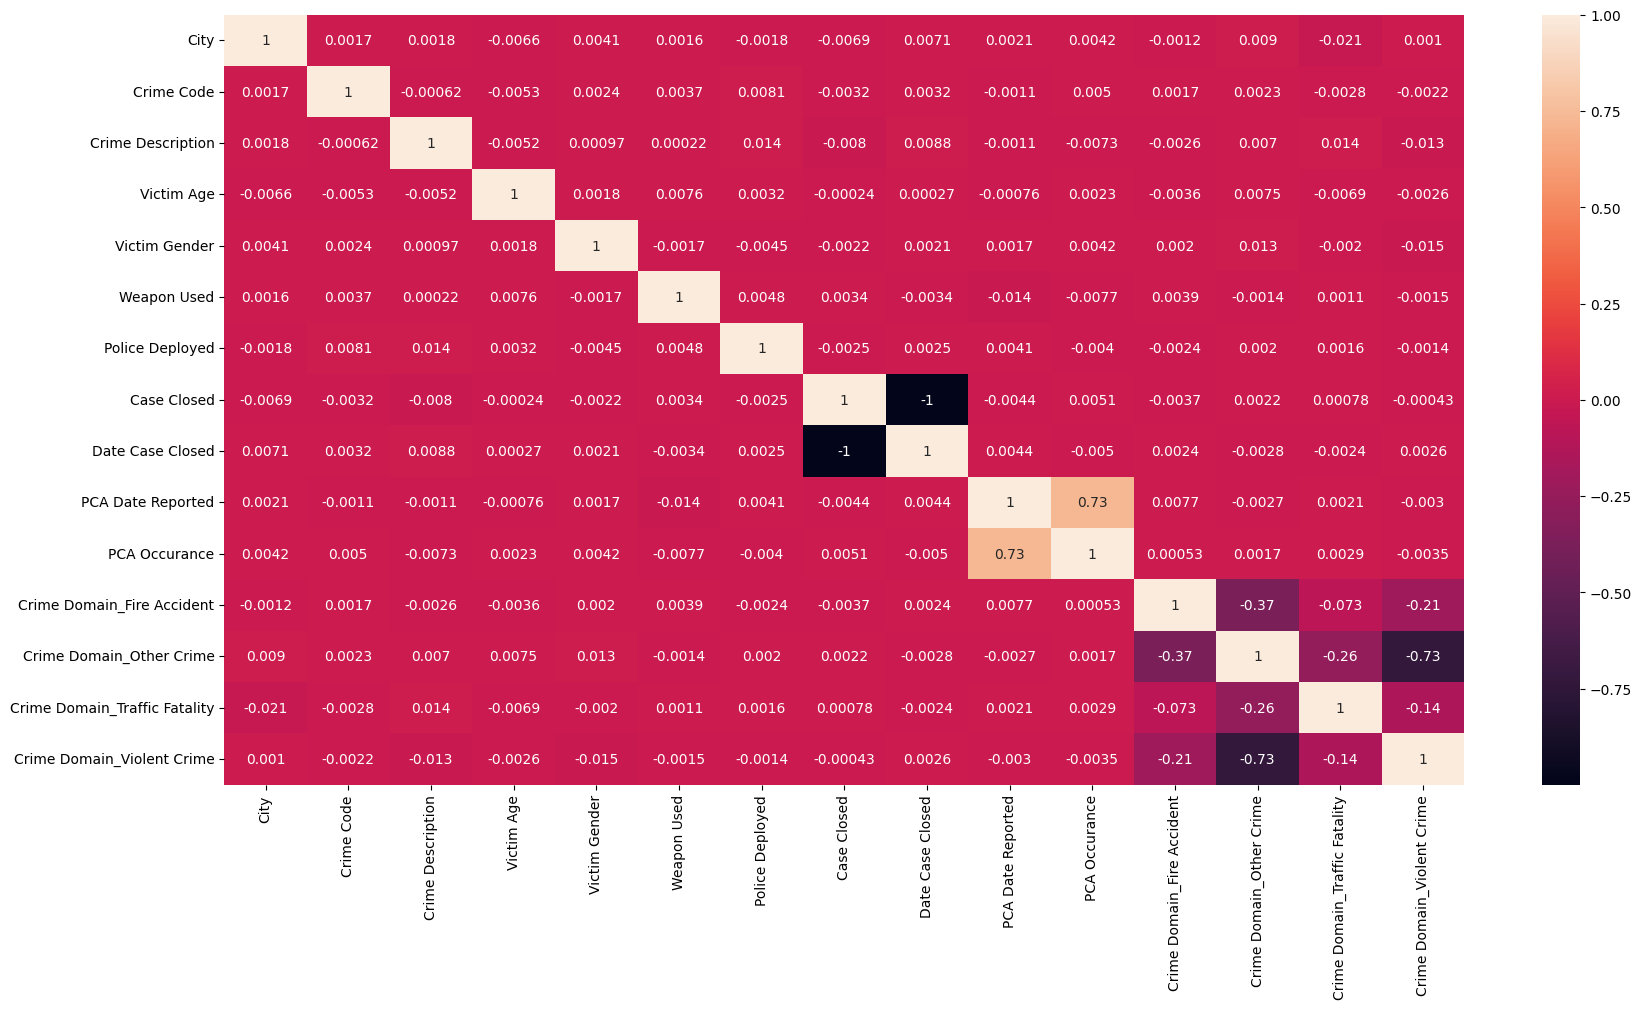

In [86]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True) 

In [87]:
df.drop(columns=['Case Closed'],inplace=True)

<Axes: >

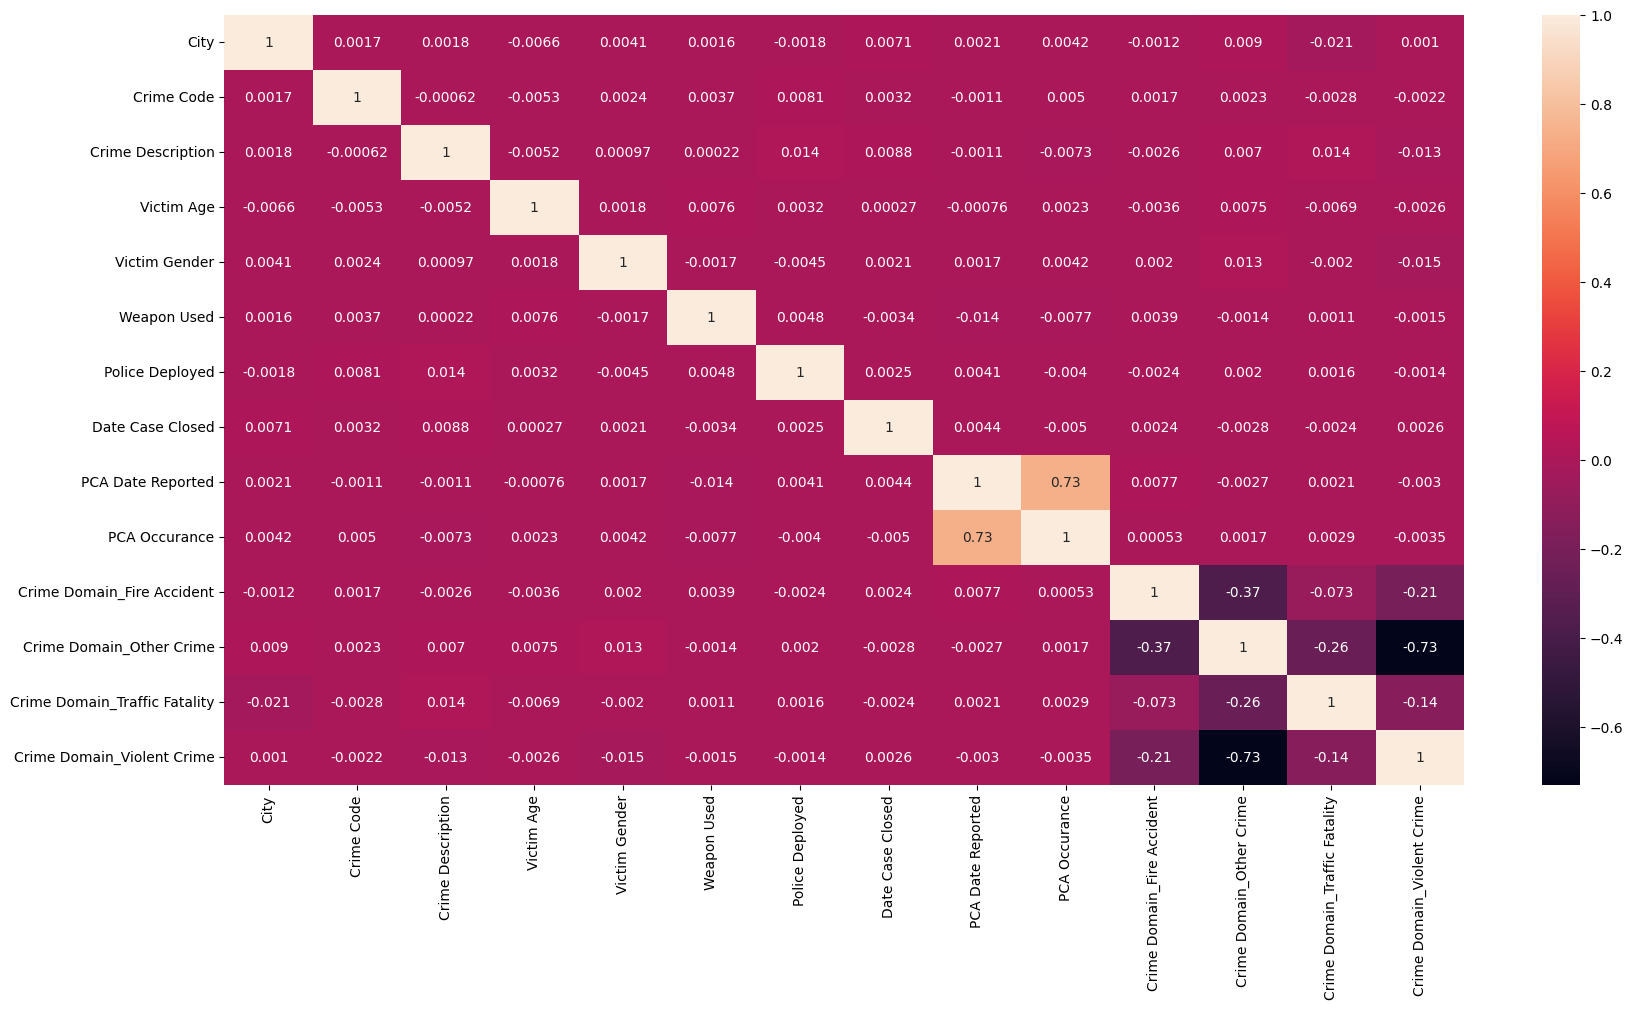

In [88]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True) 

array([[<Axes: title={'center': 'City'}>,
        <Axes: title={'center': 'Crime Code'}>,
        <Axes: title={'center': 'Crime Description'}>,
        <Axes: title={'center': 'Victim Age'}>],
       [<Axes: title={'center': 'Victim Gender'}>,
        <Axes: title={'center': 'Weapon Used'}>,
        <Axes: title={'center': 'Police Deployed'}>,
        <Axes: title={'center': 'Date Case Closed'}>],
       [<Axes: title={'center': 'PCA Date Reported'}>,
        <Axes: title={'center': 'PCA Occurance'}>,
        <Axes: title={'center': 'Crime Domain_Fire Accident'}>,
        <Axes: title={'center': 'Crime Domain_Other Crime'}>],
       [<Axes: title={'center': 'Crime Domain_Traffic Fatality'}>,
        <Axes: title={'center': 'Crime Domain_Violent Crime'}>, <Axes: >,
        <Axes: >]], dtype=object)

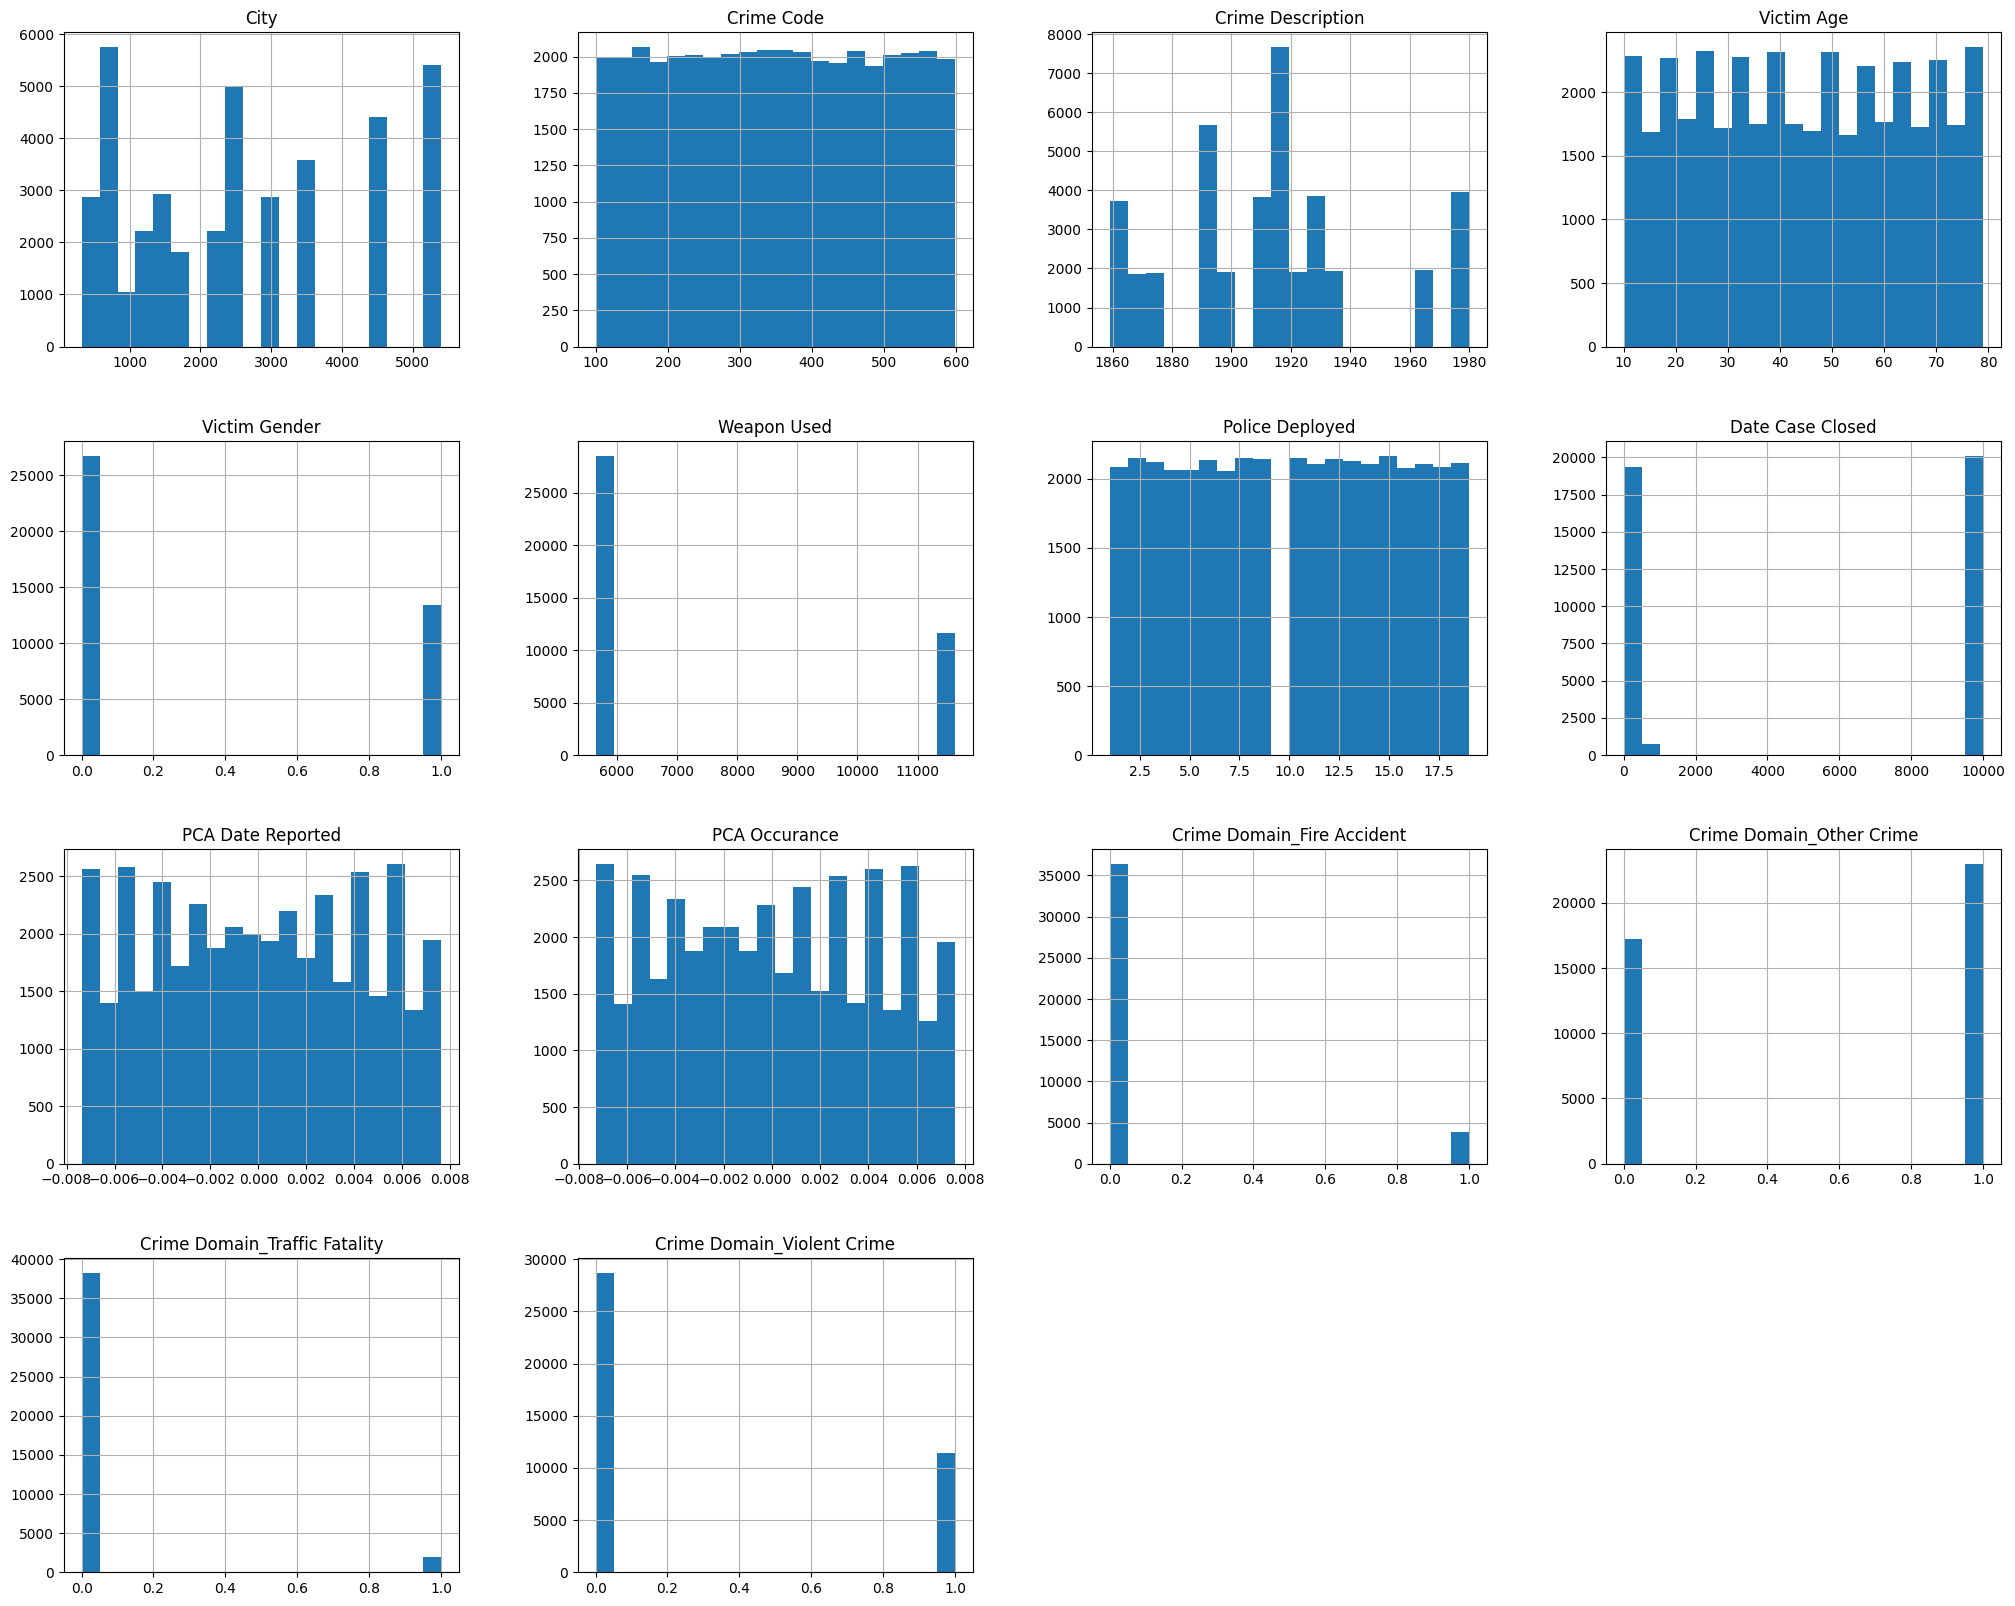

In [89]:
df.hist(figsize=(25,20),bins=20)

In [90]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [91]:
df['City'].unique()

array([1817, 2493,  761, 2212, 5400, 4415, 1111,  728, 3588, 2518,  704,
       2881, 1479, 1456,  690,  695, 1112,  355, 1053,  395,  706,  699,
        320,  362,  764,  366,  371,  354])

In [92]:
df['City']=scaler.fit_transform(df[['City']])

In [93]:
df['City'].unique

<bound method Series.unique of 0       -0.465505
1       -0.053390
2       -1.109280
3       -0.224698
4       -0.224698
           ...   
40155   -0.038150
40156    1.118330
40157   -0.895298
40158   -1.149516
40159    1.718822
Name: City, Length: 40160, dtype: float64>

In [94]:
df['Weapon Used'].unique()

array([ 5737,  5728,  5643,  5676, 11625,  5751])

In [95]:
df['Date Case Closed'].unique()

array([9.999e+03, 1.190e+02, 7.000e+00, 8.800e+01, 8.300e+01, 3.000e+01,
       5.900e+01, 2.200e+01, 6.200e+01, 1.900e+01, 6.000e+01, 7.000e+01,
       7.400e+01, 1.810e+02, 6.800e+01, 1.200e+01, 6.900e+01, 1.010e+02,
       1.000e+02, 1.500e+01, 1.960e+02, 8.600e+01, 3.500e+01, 7.200e+01,
       1.100e+01, 7.800e+01, 1.400e+01, 2.000e+01, 8.400e+01, 8.000e+00,
       7.500e+01, 1.600e+01, 6.500e+01, 8.700e+01, 3.700e+01, 1.700e+01,
       4.300e+01, 4.700e+01, 3.300e+01, 4.000e+01, 6.710e+02, 2.700e+01,
       6.600e+01, 5.100e+01, 8.900e+01, 8.500e+01, 1.330e+02, 2.900e+01,
       8.000e+01, 2.800e+01, 7.900e+01, 4.100e+01, 3.480e+02, 5.600e+01,
       6.570e+02, 1.580e+02, 1.710e+02, 7.300e+01, 1.300e+01, 4.850e+02,
       5.500e+01, 6.100e+01, 3.200e+01, 5.700e+01, 2.500e+01, 6.300e+01,
       5.200e+01, 2.000e+00, 1.000e+01, 5.990e+02, 4.200e+01, 3.600e+01,
       1.100e+02, 8.200e+01, 6.400e+01, 3.400e+01, 2.210e+02, 1.660e+02,
       7.100e+01, 4.500e+01, 8.100e+01, 1.370e+02, 

In [96]:
df['Weapon Used']=scaler.fit_transform(df[['Weapon Used']])
df['Date Case Closed']=scaler.fit_transform(df[['Date Case Closed']])

In [97]:
df['Weapon Used'].unique,df['Date Case Closed'].unique()

(<bound method Series.unique of 0       -0.627154
 1       -0.630507
 2       -0.627154
 3       -0.662176
 4       -0.649881
            ...   
 40155   -0.662176
 40156    1.566596
 40157   -0.649881
 40158   -0.627154
 40159   -0.630507
 Name: Weapon Used, Length: 40160, dtype: float64>,
 array([ 0.99893215, -0.9944817 , -1.0170791 , -1.00073633, -1.00174515,
        -1.01243856, -1.00658745, -1.01405266, -1.00598216, -1.01465795,
        -1.00638569, -1.00436806, -1.00356101, -0.98197242, -1.00477159,
        -1.01607029, -1.00456982, -0.99811342, -0.99831518, -1.015465  ,
        -0.97894598, -1.00113986, -1.01142975, -1.00396453, -1.01627205,
        -1.00275396, -1.01566676, -1.01445619, -1.00154338, -1.01687734,
        -1.00335925, -1.01526324, -1.00537687, -1.0009381 , -1.01102622,
        -1.01506147, -1.00981565, -1.0090086 , -1.01183327, -1.01042094,
        -0.88310878, -1.01304385, -1.00517511, -1.00820155, -1.00053457,
        -1.00134162, -0.99165702, -1.01264032, -1.0

In [98]:
pca=PCA(n_components=2)

In [99]:
X_df=pca.fit_transform(df)

In [100]:
X_df

array([[ 226.66137258,    5.25037579],
       [-221.3542246 ,   -3.93219545],
       [ -78.362409  ,    7.04497942],
       ...,
       [  73.62826833,  -51.05746952],
       [ -38.33829225,    4.21014256],
       [-156.36286248,   19.04018207]])

In [101]:
X_df=pd.DataFrame(X_df)
X_df.head()

,0,1
0,226.661373,5.250376
1,-221.354225,-3.932195
2,-78.362409,7.044979
3,-179.376373,66.991042
4,71.643864,62.165778


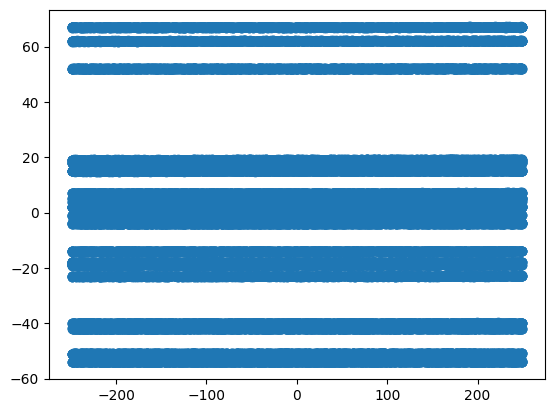

In [102]:
plt.scatter(X_df.iloc[:,0],X_df.iloc[:,1])

## K-Means

In [103]:
from sklearn.cluster import KMeans
wcss=[]

for k in range(2,10):
    kmeans=KMeans(n_clusters=k,random_state=0,n_init=12)
    kmeans.fit(X_df)
    wcss.append(kmeans.inertia_)

In [104]:
wcss

[253170979.52379432,
 135467178.6906002,
 95229507.54766595,
 76359014.1198279,
 66157095.54105068,
 60125920.43961204,
 54756078.33490035,
 49327184.11076603]

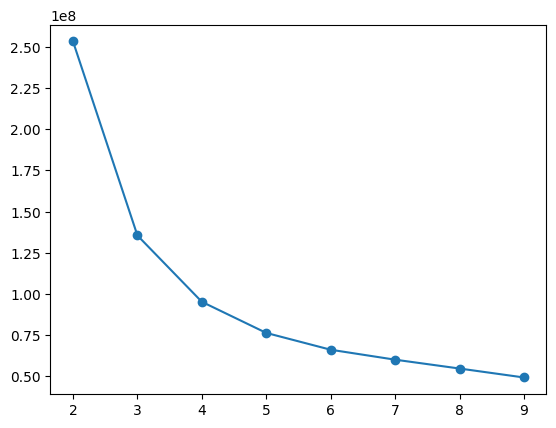

In [105]:
plt.plot(range(2,10),wcss,marker='o')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

kmean=KMeans(n_clusters=4,random_state=0,n_init=12)

In [ ]:
new_col=kmean.fit_predict(X_df)

new_col=pd.DataFrame(new_col,columns=['Cluster'])

In [ ]:
acc_score=silhouette_score(X_df,new_col)

C:\Users\nalla\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


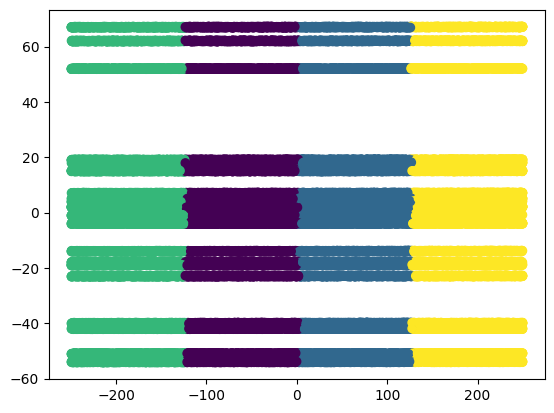

In [ ]:
plt.scatter(X_df.iloc[:,0],X_df.iloc[:,1],c=new_col.values)
plt.show()

In [107]:
acc_score

np.float64(0.450296014242034)

##  AgglomerativeClustering



In [110]:
from sklearn.cluster import AgglomerativeClustering
a_cluster=AgglomerativeClustering(n_clusters=4,linkage='ward')


In [ ]:
y_pred=a_cluster.fit_predict(df)

In [114]:
X_df=X_df.to_numpy()

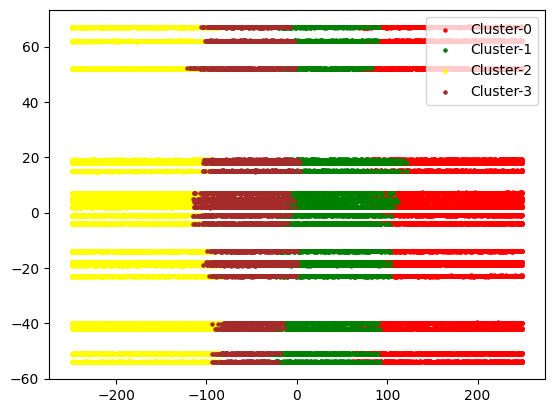

In [115]:
plt.scatter(X_df[y_pred==0,0],X_df[y_pred==0,1],s=5,c='red',label='Cluster-0')
plt.scatter(X_df[y_pred==1,0],X_df[y_pred==1,1],s=5,c='green',label='Cluster-1')
plt.scatter(X_df[y_pred==2,0],X_df[y_pred==2,1],s=5,c='yellow',label='Cluster-2')
plt.scatter(X_df[y_pred==3,0],X_df[y_pred==3,1],s=5,c='brown',label='Cluster-3')
plt.legend()
plt.show()

## Optimal Clusters are 4